# Segmentación de clientes de aerolínea — Clasificación multiclase

---

**Autor:** Borja Mora Méndez  
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · Supervisado · Clasificación · Comparativa de modelos

---

### Objetivo

Comparar tres modelos de clasificación multiclase (Regresión Logística, Random Forest y Gradient Boosting) para predecir a qué segmento pertenece cada cliente de una aerolínea (Básico, Frecuente o Premium), usando variables de comportamiento de vuelo, gasto e interacción con el programa de fidelización.

### Contexto de negocio

**El cliente:** una compañía aérea con un programa de fidelización que diferencia tres niveles de cliente.

**El problema:** Marketing quiere clasificar automáticamente a cada cliente en su segmento para lanzar campañas diferenciadas — fidelización para frecuentes, incentivos de upgrade para los que están cerca de subir, y reactivación para los básicos que pierden actividad.

**La pregunta:** con las variables de comportamiento disponibles (frecuencia de vuelo, gasto, antigüedad, incidencias, satisfacción), ¿se puede predecir el segmento con fiabilidad suficiente para usarlo en decisiones de campaña?

## 1. Setup: librerías

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Carga de datos

Cada fila es un cliente. El dataset incluye variables de demografía (1), comportamiento de vuelo (5), valor económico (1), incidencias (4), equipaje y satisfacción (2), fidelización (1) y canal de registro (5). Variable objetivo: `segmento_cliente` con tres clases (Básico, Frecuente, Premium).

In [2]:
# Ruta relativa para portabilidad del notebook.
# para que el notebook se pueda ejecutar en cualquier máquina/carpeta compartida por el equipo.
from pathlib import Path

ruta = Path("dataset_linea_aerea_multiclase_v2.xlsx")
df = pd.read_excel(ruta)

In [3]:
# Mostrar 10 filas aleatorias
df.sample(10, random_state=42)

,edad,frecuencia_viaje_anual,distancia_media_km,antelacion_media_dias,gasto_anual_eur,retrasos_ultimos_12m,cancelaciones_ultimos_12m,equipaje_medio_por_vuelo,no_shows_ultimos_12m,satisfaccion_media,...,antiguedad_programa_meses,vuelos_largo_radio_anual,vuelos_negocio_anual,canal_registro,aeropuerto_preferido,uso_codigo_promocional,numero_maletas_max_12m,dia_preferido_viaje,temperatura_ciudad_residencia,segmento_cliente
1116,22,2,3596.0,11,379.84,1,0,1.3,0,5.9,...,74.0,0,1,Agencia,CDG,0,2,0,17.7,Basico
1368,44,4,1525.0,28,364.25,0,0,1.1,0,6.2,...,26.0,1,1,Web,FRA,0,1,5,17.2,Frecuente
422,34,8,1886.0,43,1551.41,4,0,1.6,1,6.3,...,114.0,1,4,Web,BCN,0,4,3,22.8,Premium
413,30,7,784.0,72,1524.98,3,1,0.8,0,8.9,...,17.0,3,3,Web,BCN,0,3,4,20.9,Frecuente
451,37,6,3986.0,43,1220.21,0,2,1.2,0,10.0,...,58.0,2,1,App,MAD,0,1,4,18.7,Premium
861,63,5,1351.0,29,1000.40,1,0,2.1,0,6.1,...,36.0,1,2,Web,CDG,0,3,6,21.8,Basico
1063,73,4,1636.0,44,1250.41,2,2,1.6,0,6.7,...,12.0,2,3,App,LIS,0,0,6,10.1,Frecuente
741,49,6,3333.0,60,1452.52,3,0,1.4,2,4.9,...,7.0,4,0,Web,LHR,0,4,1,19.2,Premium
1272,63,5,2123.0,44,409.64,6,0,1.8,0,5.6,...,37.0,2,1,App,MAD,0,2,1,10.5,Frecuente
259,65,4,2443.0,51,482.57,3,0,1.3,0,6.2,...,12.0,1,1,App,CDG,0,4,5,22.4,Frecuente


In [4]:
# Dimensiones del dataset
filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de variables: {columnas}")

Número de registros: 1500
Número de variables: 21


In [5]:
# FICHA DE VARIABLES
variables = pd.DataFrame({
    "Nº": range(1, len(df.columns) + 1),
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "Nulos": df.isna().sum().values,
    "Nulos %": (df.isna().mean() * 100).round(2).values
})

variables

,Nº,Variable,Tipo,Nulos,Nulos %
0,1,edad,int64,0,0.00
1,2,frecuencia_viaje_anual,int64,0,0.00
2,3,distancia_media_km,float64,30,2.00
3,4,antelacion_media_dias,int64,0,0.00
4,5,gasto_anual_eur,float64,37,2.47
5,6,retrasos_ultimos_12m,int64,0,0.00
6,7,cancelaciones_ultimos_12m,int64,0,0.00
7,8,equipaje_medio_por_vuelo,float64,0,0.00
8,9,no_shows_ultimos_12m,int64,0,0.00
9,10,satisfaccion_media,float64,52,3.47


In [6]:
#Clasificación automatica de variables

variables_numericas = df.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()
variables_booleanas = df.select_dtypes(include="bool").columns.tolist()
variables_fechas = df.select_dtypes(include=["datetime"]).columns.tolist()


print("VARIABLES NUMÉRICAS")
print(variables_numericas)

print("\nVARIABLES CATEGÓRICAS")
print(variables_categoricas)

print("\nVARIABLES BOOLEANAS")
print(variables_booleanas)

print("\nVARIABLES DE FECHA")
print(variables_fechas)

VARIABLES NUMÉRICAS
['edad', 'frecuencia_viaje_anual', 'distancia_media_km', 'antelacion_media_dias', 'gasto_anual_eur', 'retrasos_ultimos_12m', 'cancelaciones_ultimos_12m', 'equipaje_medio_por_vuelo', 'no_shows_ultimos_12m', 'satisfaccion_media', 'quejas_ultimos_12m', 'antiguedad_programa_meses', 'vuelos_largo_radio_anual', 'vuelos_negocio_anual', 'uso_codigo_promocional', 'numero_maletas_max_12m', 'dia_preferido_viaje', 'temperatura_ciudad_residencia']

VARIABLES CATEGÓRICAS
['canal_registro', 'aeropuerto_preferido', 'segmento_cliente']

VARIABLES BOOLEANAS
[]

VARIABLES DE FECHA
[]


/tmp/ipykernel_2548/866527403.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:
# Diccionario con estadísticas de las variables

diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "Valores no nulos": df.notna().sum().values,
    "Valores nulos": df.isna().sum().values,
    "% nulos": (df.isna().mean() * 100).round(2).values,
    "Valores únicos": df.nunique().values
})

diccionario

,Variable,Tipo,Valores no nulos,Valores nulos,% nulos,Valores únicos
0,edad,int64,1500,0,0.00,58
1,frecuencia_viaje_anual,int64,1500,0,0.00,19
2,distancia_media_km,float64,1470,30,2.00,1157
3,antelacion_media_dias,int64,1500,0,0.00,146
4,gasto_anual_eur,float64,1463,37,2.47,1454
5,retrasos_ultimos_12m,int64,1500,0,0.00,9
6,cancelaciones_ultimos_12m,int64,1500,0,0.00,6
7,equipaje_medio_por_vuelo,float64,1500,0,0.00,28
8,no_shows_ultimos_12m,int64,1500,0,0.00,5
9,satisfaccion_media,float64,1448,52,3.47,73


In [8]:
# CORREGIDO: el chequeo original buscaba una columna llamada 'target' que no existe
# en este dataset. Se adapta a la variable objetivo real: 'segmento_cliente'.

TARGET = "segmento_cliente"

n_valores_target = df[TARGET].nunique(dropna=False)
print(f"Valores únicos en {TARGET}: {n_valores_target}")

if n_valores_target <= 10:
    print("-> Probable problema de CLASIFICACIÓN")
    print()
    print("Distribución de clases:")
    print((df[TARGET].value_counts(normalize=True).round(3) * 100))
else:
    print("-> Probable problema de REGRESIÓN")
    print()
    print(df[TARGET].describe())

Valores únicos en segmento_cliente: 3
-> Probable problema de CLASIFICACIÓN

Distribución de clases:
segmento_cliente
Frecuente    36.0
Basico       36.0
Premium      28.0
Name: proportion, dtype: float64


## 3. Calidad del dato

In [9]:
# Valores nulos

# Número de valores nulos por variable
valores_nulos = df.isnull().sum()

# Porcentaje de valores nulos por variable
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

# Ordenar de mayor a menor porcentaje de nulos
porcentaje_nulos.sort_values(ascending=False)

satisfaccion_media               3.47
gasto_anual_eur                  2.47
distancia_media_km               2.00
antiguedad_programa_meses        2.00
aeropuerto_preferido             1.47
antelacion_media_dias            0.00
frecuencia_viaje_anual           0.00
edad                             0.00
retrasos_ultimos_12m             0.00
no_shows_ultimos_12m             0.00
equipaje_medio_por_vuelo         0.00
quejas_ultimos_12m               0.00
cancelaciones_ultimos_12m        0.00
vuelos_largo_radio_anual         0.00
vuelos_negocio_anual             0.00
canal_registro                   0.00
uso_codigo_promocional           0.00
numero_maletas_max_12m           0.00
dia_preferido_viaje              0.00
temperatura_ciudad_residencia    0.00
segmento_cliente                 0.00
dtype: float64

In [10]:
nulos = pd.DataFrame({
    "Variable": df.columns,
    "Nulos": df.isnull().sum(),
    "% Nulos": round(df.isnull().mean()*100,2)
})

In [11]:
#FILTRADO DE VARIBLES CON NULOS
nulos[nulos["Nulos"]> 0]

,Variable,Nulos,% Nulos
distancia_media_km,distancia_media_km,30,2.00
gasto_anual_eur,gasto_anual_eur,37,2.47
satisfaccion_media,satisfaccion_media,52,3.47
antiguedad_programa_meses,antiguedad_programa_meses,30,2.00
aeropuerto_preferido,aeropuerto_preferido,22,1.47


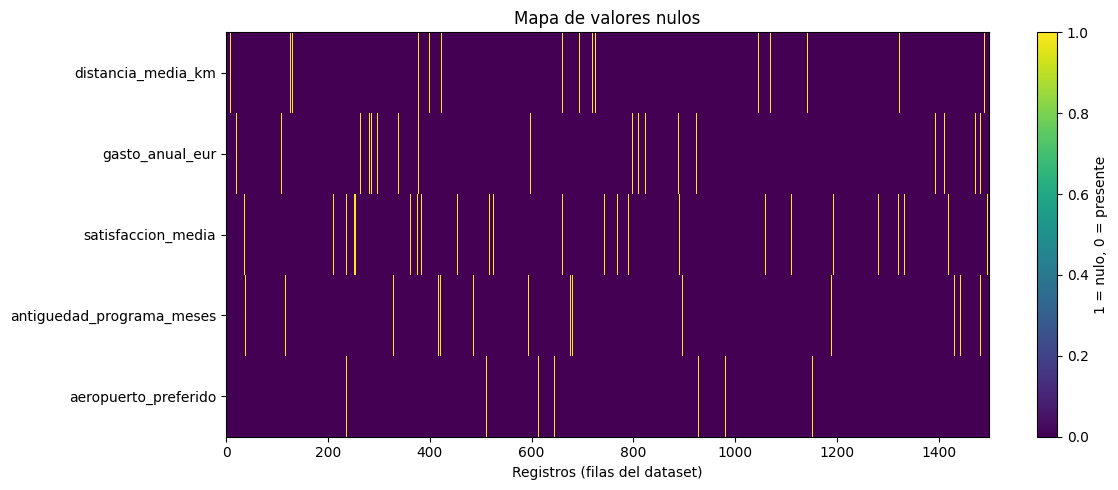

In [12]:
# Mapa de nulos: cada fila del dataset, cada columna con nulos.
# Amarillo = valor nulo, morado = valor presente.

columnas_con_nulos = nulos[nulos["Nulos"] > 0]["Variable"].tolist()

if columnas_con_nulos:
    plt.figure(figsize=(12, 5))
    plt.imshow(
        df[columnas_con_nulos].isna().T,
        aspect="auto",
        cmap="viridis",
        interpolation="none"
    )
    plt.yticks(range(len(columnas_con_nulos)), columnas_con_nulos)
    plt.xlabel("Registros (filas del dataset)")
    plt.title("Mapa de valores nulos")
    plt.colorbar(label="1 = nulo, 0 = presente")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas con nulos: no aplica el mapa de patrón de nulos.")

In [13]:
#Duplicados
duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")

Duplicados encontrados: 0


In [14]:
# Cardinalidad: numero de valores distintos que tiene una variable

cardinalidad = pd.DataFrame({
    "Variable": df.columns,
    "Valores unicos": df.nunique()
})

cardinalidad.sort_values("Valores unicos", ascending=False)

,Variable,Valores unicos
gasto_anual_eur,gasto_anual_eur,1454
distancia_media_km,distancia_media_km,1157
temperatura_ciudad_residencia,temperatura_ciudad_residencia,282
antiguedad_programa_meses,antiguedad_programa_meses,158
antelacion_media_dias,antelacion_media_dias,146
satisfaccion_media,satisfaccion_media,73
edad,edad,58
equipaje_medio_por_vuelo,equipaje_medio_por_vuelo,28
frecuencia_viaje_anual,frecuencia_viaje_anual,19
vuelos_negocio_anual,vuelos_negocio_anual,10


In [15]:
# Frecuencia de variables categoricas

for columna in variables_categoricas:

    # Separador visual
    print("=" * 50)

    # Nombre de la variable
    print(f"Variable: {columna}")

    # Frecuencia de cada categoría.
    # dropna=False incluye también los valores nulos.
    print(df[columna].value_counts(dropna=False))

    # Espacio entre variables
    print()

Variable: canal_registro
canal_registro
Web         638
App         513
Agencia     212
Telefono    137
Name: count, dtype: int64

Variable: aeropuerto_preferido
aeropuerto_preferido
BCN    283
LIS    254
MAD    252
LHR    250
CDG    222
FRA    217
NaN     22
Name: count, dtype: int64

Variable: segmento_cliente
segmento_cliente
Frecuente    540
Basico       540
Premium      420
Name: count, dtype: int64



In [16]:
# Valores imposibles - automatizacion para su deteccion. 

# Definimos las reglas de negocio para cada variable. Cada variable tiene un valor mínimo y máximo permitido.

reglas = {
    "edad": (18, 90),
    "satisfaccion_media": (0, 10),
    "numero_maletas_max_12m": (0,12)
}


# Recorremos cada variable y sus límites
for variable, (minimo, maximo) in reglas.items():

    # Detectamos los registros fuera del rango permitido.
    #
    # Un valor se considera incorrecto si:
    # - Es menor que el valor mínimo permitido
    # - O es mayor que el valor máximo permitido
    errores = df[
        (df[variable] < minimo) |
        (df[variable] > maximo)
    ]

    # Mostramos el número de registros fuera de rango
    print(f"{variable}: {len(errores)} registros fuera de rango")

edad: 0 registros fuera de rango
satisfaccion_media: 0 registros fuera de rango
numero_maletas_max_12m: 0 registros fuera de rango


## 4. Estadística descriptiva

In [17]:
#Estadísticas básicas

df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,1500.0,46.646000,16.558889,18.0,33.00,47.00,61.00,75.000000
frecuencia_viaje_anual,1500.0,5.996000,2.482222,1.0,4.00,6.00,7.00,27.000000
distancia_media_km,1470.0,1772.847844,1289.143841,200.0,908.50,1400.50,2243.00,8000.000000
antelacion_media_dias,1500.0,48.595333,30.871955,2.0,26.00,42.00,64.00,180.000000
gasto_anual_eur,1463.0,1216.721781,536.046821,80.0,845.73,1171.34,1536.20,4313.609548
retrasos_ultimos_12m,1500.0,2.019333,1.405801,0.0,1.00,2.00,3.00,8.000000
cancelaciones_ultimos_12m,1500.0,0.670667,0.833468,0.0,0.00,0.00,1.00,5.000000
equipaje_medio_por_vuelo,1500.0,1.143600,0.437005,0.0,0.80,1.10,1.40,2.700000
no_shows_ultimos_12m,1500.0,0.425333,0.648618,0.0,0.00,0.00,1.00,5.000000
satisfaccion_media,1448.0,7.179558,1.528037,1.5,6.20,7.10,8.30,10.000000


In [18]:
# Coeficiente de variación

# CV = DesvStd / Media 
#Interpretación 
# < 10 %          → Muy homogenea
# 10 % – 30 %     → Variabilidad moderada
# > 30 %          → Alta dispersión

medias = df[variables_numericas].mean()
desviaciones = df[variables_numericas].std()

coeficiente_variacion = (
    desviaciones / medias.abs()
) * 100

coeficiente_variacion.sort_values(ascending=False)

uso_codigo_promocional           182.004209
no_shows_ultimos_12m             152.496404
cancelaciones_ultimos_12m        124.274591
quejas_ultimos_12m               114.498601
antiguedad_programa_meses         89.621436
vuelos_largo_radio_anual          75.721103
distancia_media_km                72.715989
numero_maletas_max_12m            72.186321
retrasos_ultimos_12m              69.617096
vuelos_negocio_anual              68.825814
dia_preferido_viaje               64.468096
antelacion_media_dias             63.528642
gasto_anual_eur                   44.056647
frecuencia_viaje_anual            41.397962
equipaje_medio_por_vuelo          38.213064
edad                              35.499055
temperatura_ciudad_residencia     31.632515
satisfaccion_media                21.283159
dtype: float64

In [19]:
# Rango

# Distancia existe entre el valor máximo y el valor mínimo de una variable.

rango = (
    df[variables_numericas].max()
    -
    df[variables_numericas].min()
)
rango

edad                               57.000000
frecuencia_viaje_anual             26.000000
distancia_media_km               7800.000000
antelacion_media_dias             178.000000
gasto_anual_eur                  4233.609548
retrasos_ultimos_12m                8.000000
cancelaciones_ultimos_12m           5.000000
equipaje_medio_por_vuelo            2.700000
no_shows_ultimos_12m                5.000000
satisfaccion_media                  8.500000
quejas_ultimos_12m                  5.000000
antiguedad_programa_meses         178.000000
vuelos_largo_radio_anual            6.000000
vuelos_negocio_anual                9.000000
uso_codigo_promocional              1.000000
numero_maletas_max_12m              4.000000
dia_preferido_viaje                 6.000000
temperatura_ciudad_residencia      38.100000
dtype: float64

In [20]:
# PERCENTILES

# Los percentiles dividen los datos ordenados en 100 partes. Un percentil indica el valor por debajo del cual se encuentra un determinado porcentaje de las observaciones.

# Ejemplo:
# P90 = el 90 % de los datos tiene un valor igual o inferior a ese valor. Utilizamos diferentes percentiles para analizar la distribución de las variables numéricas y detectar posibles valores extremos.

percentiles = df[variables_numericas].quantile(
    [
        0.01,  # P1
        0.05,  # P5
        0.10,  # P10
        0.25,  # P25 - Primer cuartil (Q1)
        0.50,  # P50 - Mediana
        0.75,  # P75 - Tercer cuartil (Q3)
        0.90,  # P90
        0.95,  # P95
        0.99   # P99
    ]
).T

percentiles

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
edad,18.0000,20.000,23.000,33.00,47.00,61.00,69.000,73.000,75.000000
frecuencia_viaje_anual,2.0000,3.000,3.000,4.00,6.00,7.00,9.000,10.000,12.000000
distancia_media_km,326.2800,481.900,598.900,908.50,1400.50,2243.00,3384.600,4386.000,6684.770000
antelacion_media_dias,5.0000,10.000,15.000,26.00,42.00,64.00,91.000,109.000,146.010000
gasto_anual_eur,185.4778,425.979,571.878,845.73,1171.34,1536.20,1889.162,2142.354,2763.435939
retrasos_ultimos_12m,0.0000,0.000,0.000,1.00,2.00,3.00,4.000,5.000,6.000000
cancelaciones_ultimos_12m,0.0000,0.000,0.000,0.00,0.00,1.00,2.000,2.000,3.000000
equipaje_medio_por_vuelo,0.2000,0.400,0.600,0.80,1.10,1.40,1.700,1.800,2.100000
no_shows_ultimos_12m,0.0000,0.000,0.000,0.00,0.00,1.00,1.000,2.000,2.000000
satisfaccion_media,3.6470,4.700,5.200,6.20,7.10,8.30,9.300,9.965,10.000000


In [21]:
# IQR (rango intercuartilico) medida que no se e afectada por el extremos

# El IQR mide la dispersión del 50 % central de los datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1).

# IQR = Q3 - Q1

# Es una medida de dispersión robusta, ya que los valores extremos tienen poca influencia sobre su resultado.

# Primer cuartil: el 25 % de los datos se encuentra por debajo
Q1 = df[variables_numericas].quantile(0.25)

# Tercer cuartil: el 75 % de los datos se encuentra por debajo
Q3 = df[variables_numericas].quantile(0.75)

# Rango intercuartílico
IQR = Q3 - Q1

IQR

edad                               28.00
frecuencia_viaje_anual              3.00
distancia_media_km               1334.50
antelacion_media_dias              38.00
gasto_anual_eur                   690.47
retrasos_ultimos_12m                2.00
cancelaciones_ultimos_12m           1.00
equipaje_medio_por_vuelo            0.60
no_shows_ultimos_12m                1.00
satisfaccion_media                  2.10
quejas_ultimos_12m                  1.00
antiguedad_programa_meses          49.75
vuelos_largo_radio_anual            1.00
vuelos_negocio_anual                2.00
uso_codigo_promocional              0.00
numero_maletas_max_12m              2.00
dia_preferido_viaje                 4.00
temperatura_ciudad_residencia       8.10
dtype: float64

In [22]:
# Asimetria

# skew Interpretacion
# =0     Simetrica
# >0     Cola derecha
# <0     Cola Izquierda

asimetria = df[variables_numericas].skew()
asimetria

edad                            -0.026118
frecuencia_viaje_anual           1.499916
distancia_media_km               1.922294
antelacion_media_dias            1.093187
gasto_anual_eur                  0.730631
retrasos_ultimos_12m             0.773535
cancelaciones_ultimos_12m        1.218810
equipaje_medio_por_vuelo         0.039123
no_shows_ultimos_12m             1.571337
satisfaccion_media              -0.119317
quejas_ultimos_12m               1.168818
antiguedad_programa_meses        1.418332
vuelos_largo_radio_anual         0.670987
vuelos_negocio_anual             0.756554
uso_codigo_promocional           1.271086
numero_maletas_max_12m           0.031946
dia_preferido_viaje             -0.044031
temperatura_ciudad_residencia    0.014816
dtype: float64

In [23]:
#Kurtosis 

# La kurtosis mide el comportamiento de las colas de una distribución y ayuda a identificar si existen más o menos valores extremos que en una distribución normal.

# Pandas devuelve la "kurtosis en exceso":

# Kurtosis ≈ 0  → Mesocúrtica
# Kurtosis > 0   → Leptocúrtica
# Kurtosis < 0   → Platicúrtica

# IMPORTANTE:
# La kurtosis no debe interpretarse únicamente como una medida de "apuntamiento". En EDA es especialmente útil para analizar el peso de las colas y la presencia potencial de valores extremos.

kurtosis = df[variables_numericas].kurtosis()
kurtosis

edad                            -1.159773
frecuencia_viaje_anual           8.237719
distancia_media_km               4.682991
antelacion_media_dias            1.259493
gasto_anual_eur                  1.393066
retrasos_ultimos_12m             0.705660
cancelaciones_ultimos_12m        1.297157
equipaje_medio_por_vuelo        -0.137215
no_shows_ultimos_12m             2.944044
satisfaccion_media              -0.317197
quejas_ultimos_12m               1.494007
antiguedad_programa_meses        1.709889
vuelos_largo_radio_anual         0.144086
vuelos_negocio_anual             0.903301
uso_codigo_promocional          -0.384856
numero_maletas_max_12m          -1.301486
dia_preferido_viaje             -1.209896
temperatura_ciudad_residencia   -0.042769
dtype: float64

## 5. Análisis univariante

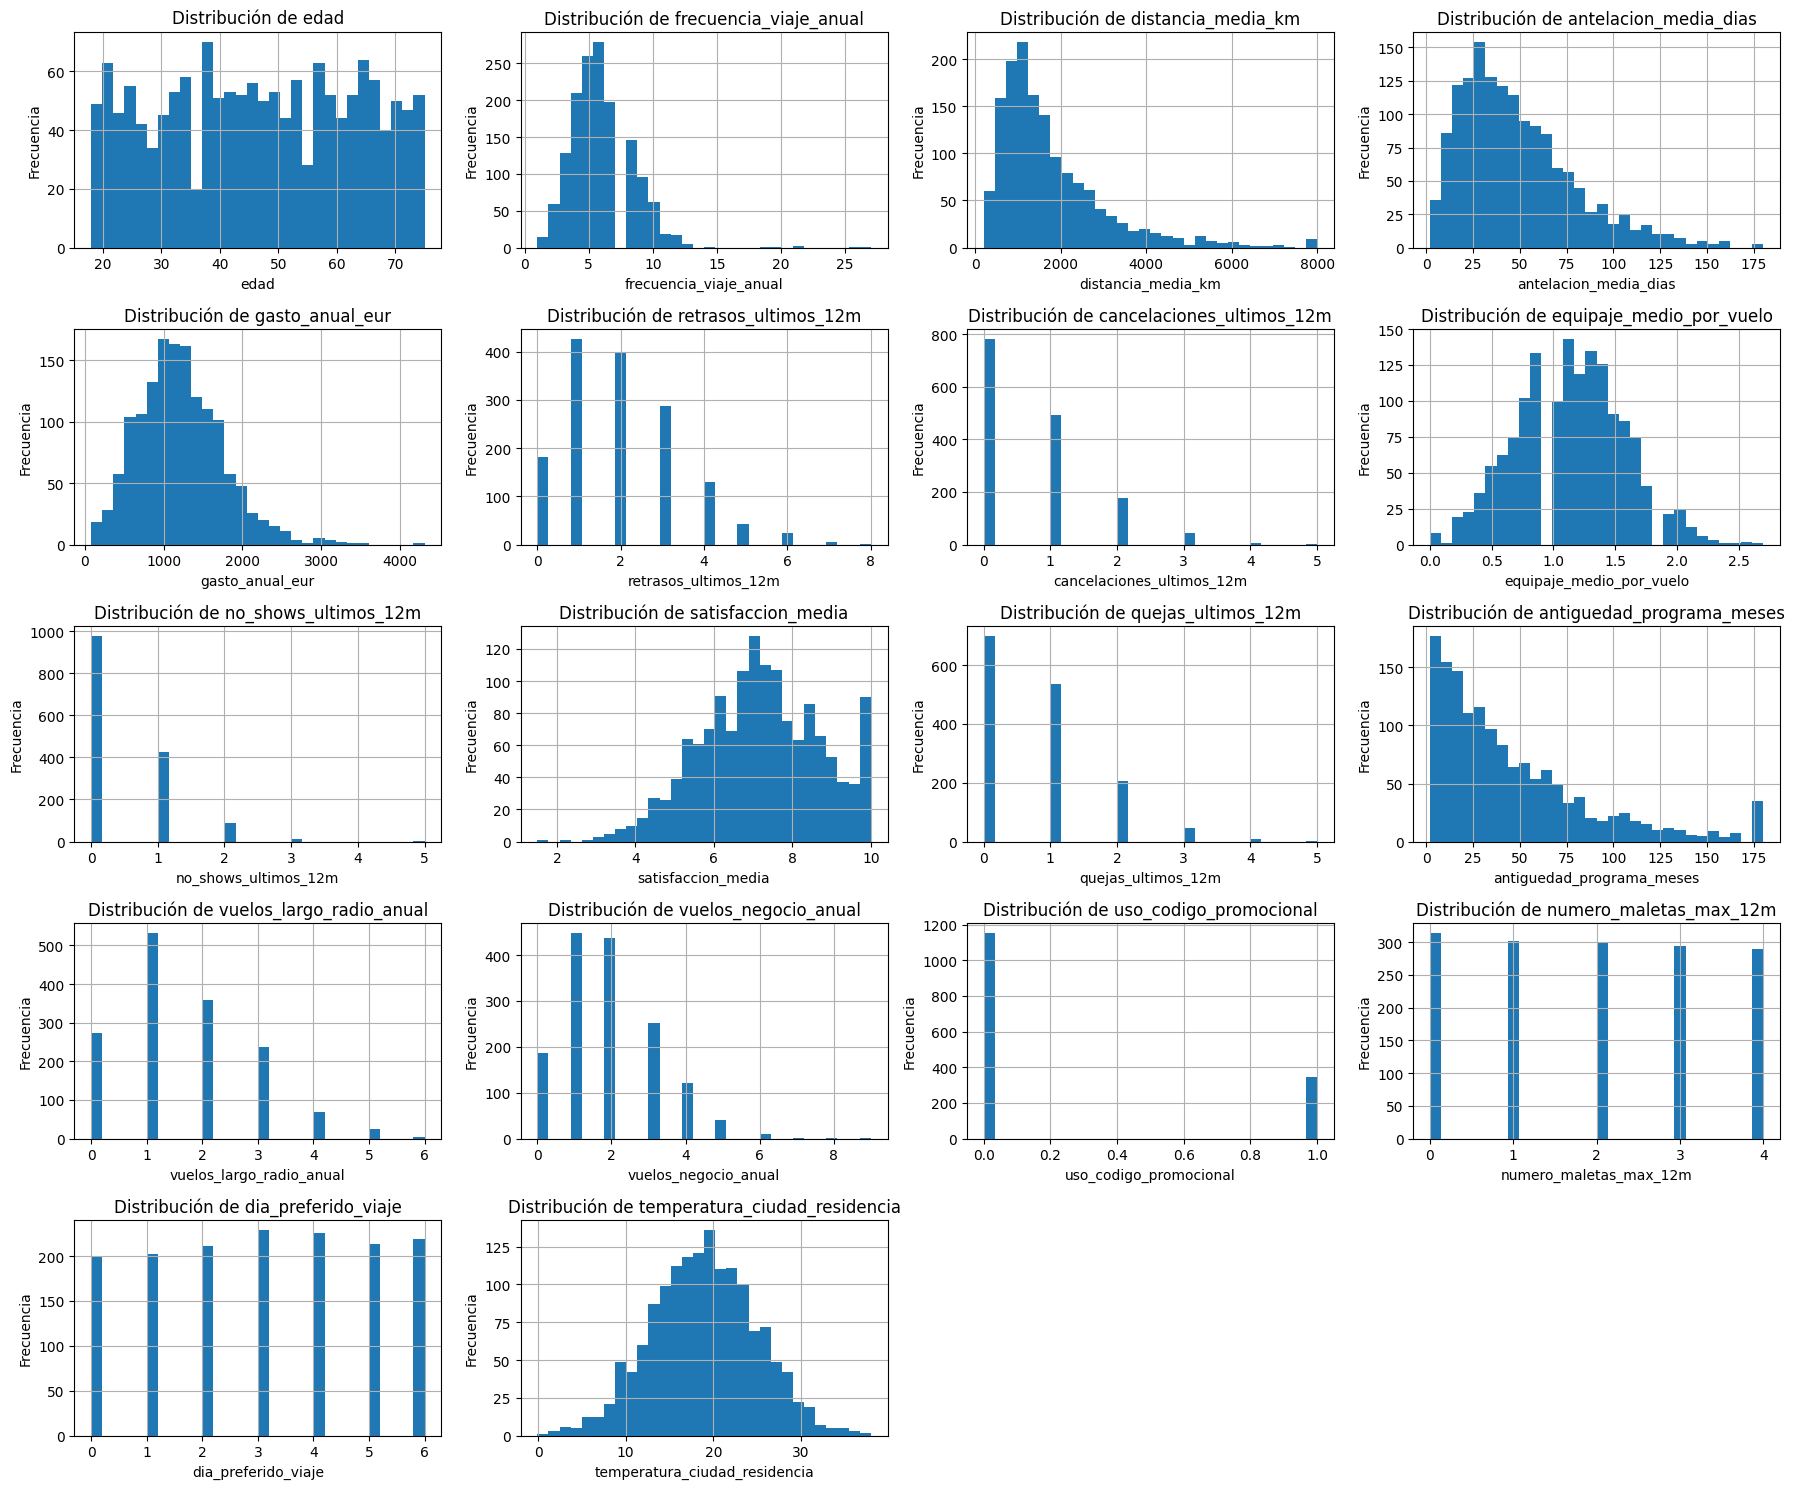

In [24]:
n_columnas = 4
n_filas = int(np.ceil(len(variables_numericas) / n_columnas))

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 3 * n_filas)
)

axes = np.array(axes).flatten()

for i, variable in enumerate(variables_numericas):

    axes[i].hist(
        df[variable].dropna(),
        bins=30
    )

    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True)


for i in range(len(variables_numericas), len(axes)):
    axes[i].set_visible(False)


plt.tight_layout()

plt.show()

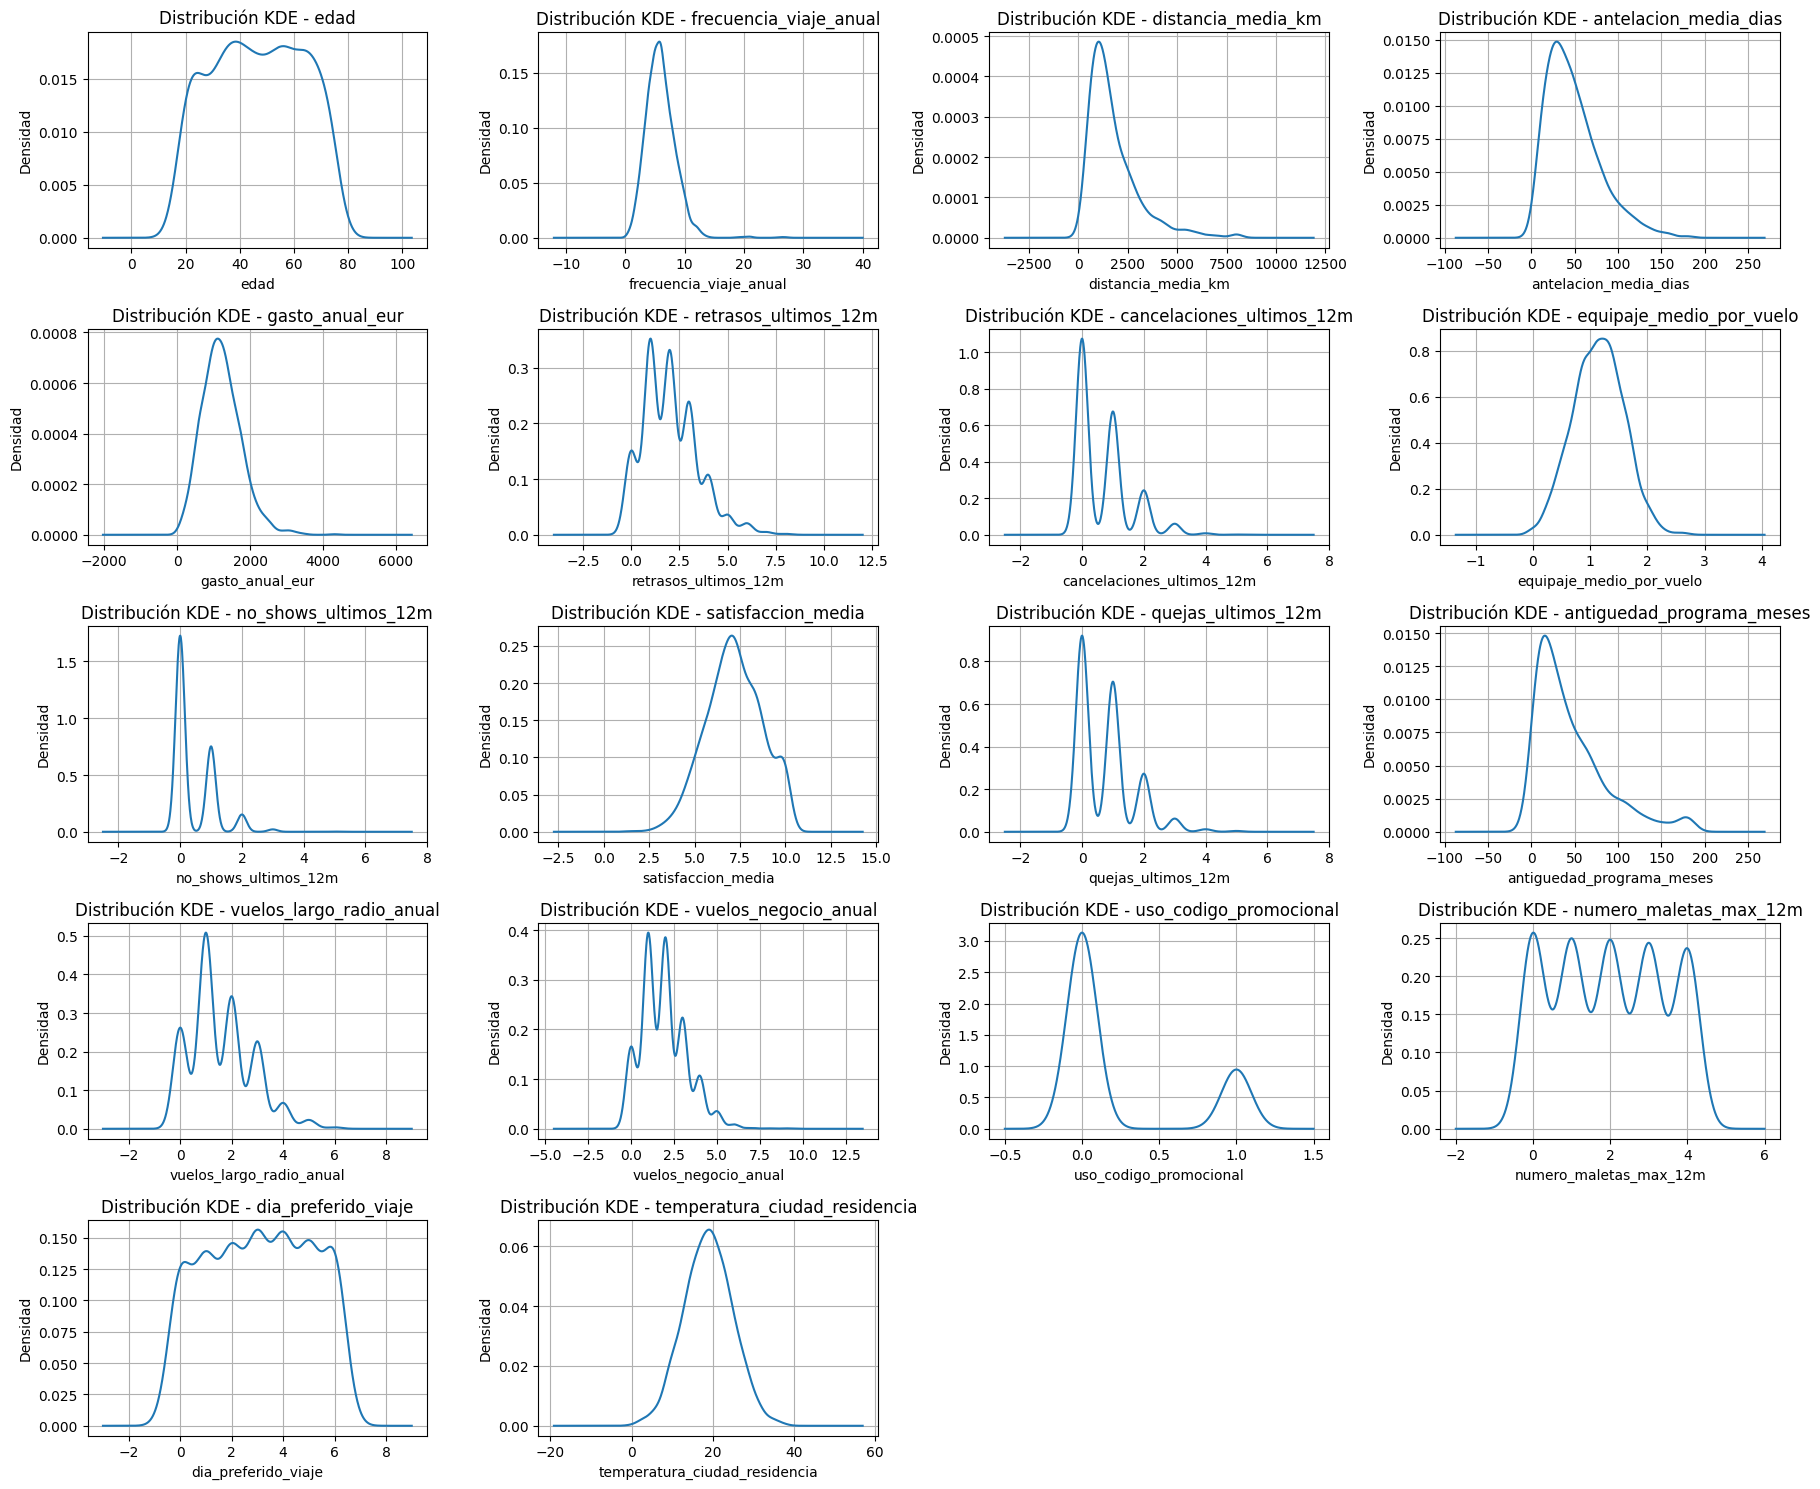

In [25]:
#Curvas KDE permite detectar multimodalidad y sesgo

# KDE (Kernel Density Estimation) permite visualizar la distribución suavizada de una variable numérica.
#
# Es útil para identificar:
# - La forma de la distribución
# - Sesgo hacia la derecha o izquierda
# - Concentración de los datos
# - Posibles distribuciones multimodales
#
# Creamos una cuadrícula de 3 columnas.

n_columnas = 4
n_filas = int(np.ceil(len(variables_numericas) / n_columnas))

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 3 * n_filas)
)

axes = np.array(axes).flatten()


for i, variable in enumerate(variables_numericas):

    df[variable].dropna().plot(
        kind="kde",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución KDE - {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Densidad")
    axes[i].grid(True)


for i in range(len(variables_numericas), len(axes)):
    axes[i].set_visible(False)


plt.tight_layout()

plt.show()

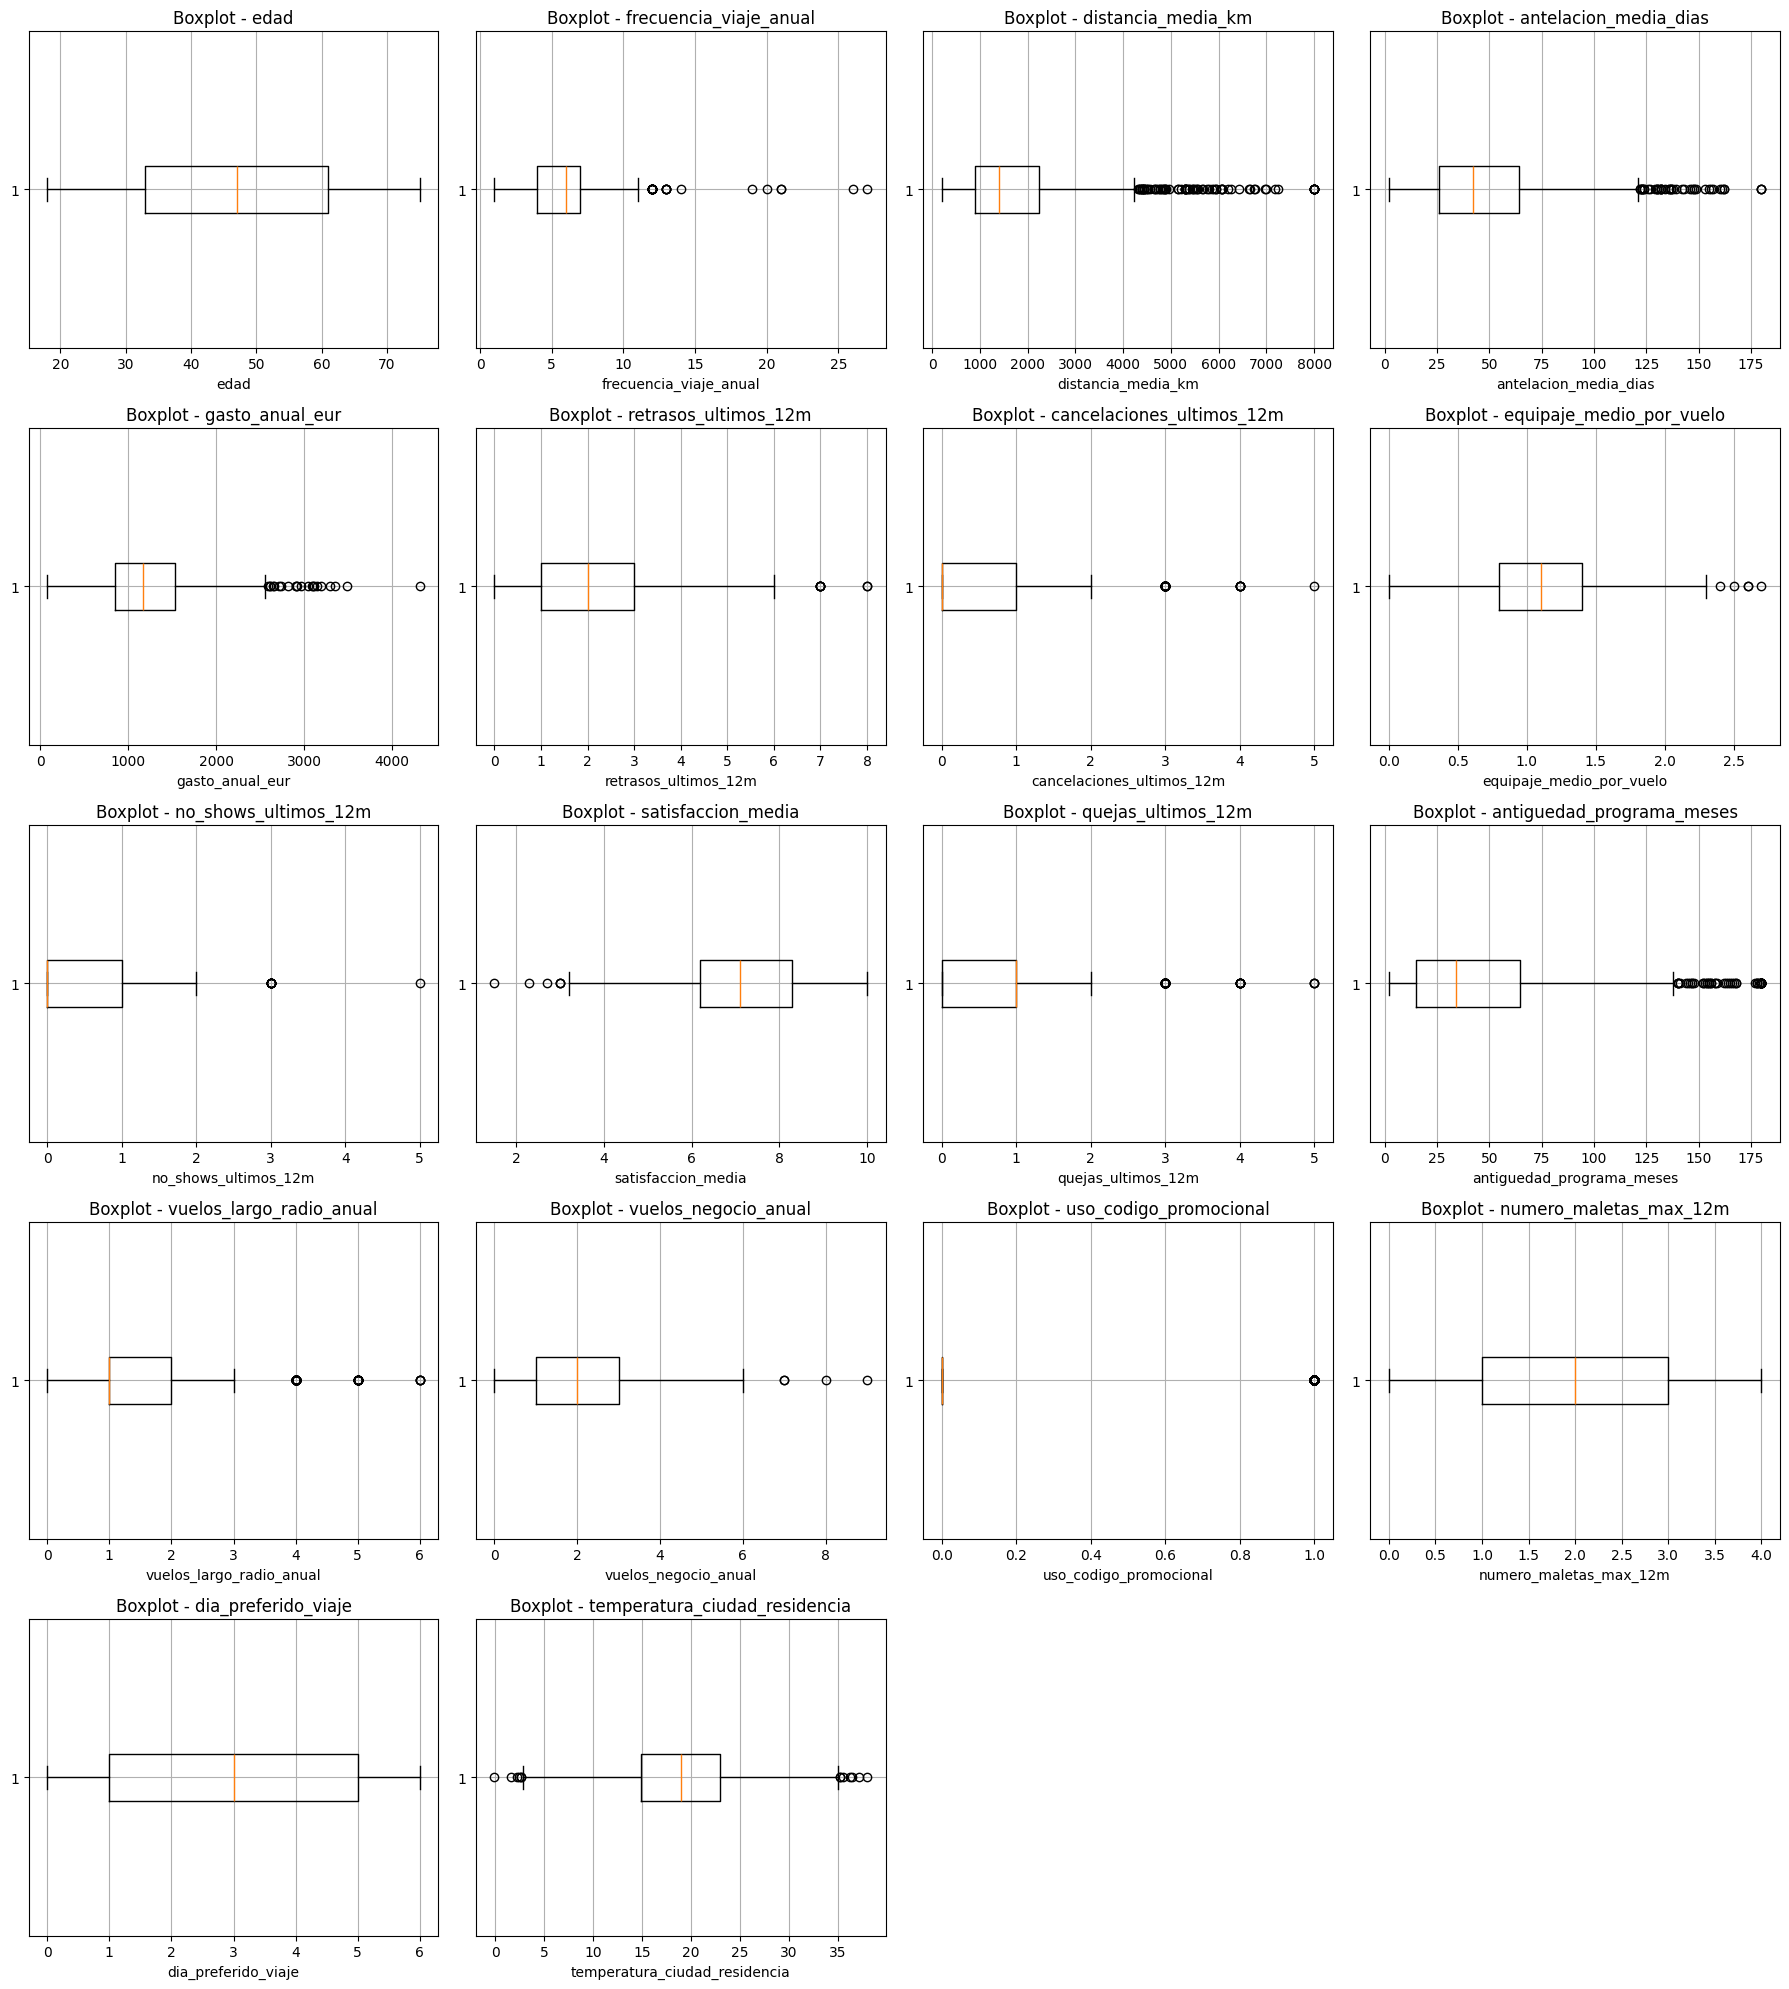

In [26]:
# Box-plot

n_columnas = 4
n_filas = int(np.ceil(len(variables_numericas) / n_columnas))

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 4 * n_filas)
)

axes = np.array(axes).flatten()


for i, variable in enumerate(variables_numericas):

    axes[i].boxplot(
        df[variable].dropna(),
        vert=False
    )

    axes[i].set_title(f"Boxplot - {variable}")
    axes[i].set_xlabel(variable)
    axes[i].grid(True)


for i in range(len(variables_numericas), len(axes)):
    axes[i].set_visible(False)


plt.tight_layout()

plt.show()

In [27]:
# Conceptualmente vamos a evaluar un Test de normalidad

#HO: la distribuaciñin de la variable a estudio sigue una distribucion NORMAL
#Lo vamos a validar con p-valor (0.05)

# Esto me vale por si es necesario realizar alguna transformación de lo anterior visto

from scipy import stats

for variable in variables_numericas:
    stat, p = stats.shapiro(
        df[variable]
        .dropna()
        .sample(
            min(
                500,
                len(df[variable].dropna())
            ),
            random_state=42
        )
    )

    print(variable)
    print("p =", round(p, 4))
    print()

edad
p = 0.0

frecuencia_viaje_anual
p = 0.0

distancia_media_km
p = 0.0

antelacion_media_dias
p = 0.0

gasto_anual_eur
p = 0.0

retrasos_ultimos_12m
p = 0.0

cancelaciones_ultimos_12m
p = 0.0

equipaje_medio_por_vuelo
p = 0.0135

no_shows_ultimos_12m
p = 0.0

satisfaccion_media
p = 0.0002

quejas_ultimos_12m
p = 0.0

antiguedad_programa_meses
p = 0.0

vuelos_largo_radio_anual
p = 0.0

vuelos_negocio_anual
p = 0.0

uso_codigo_promocional
p = 0.0

numero_maletas_max_12m
p = 0.0

dia_preferido_viaje
p = 0.0

temperatura_ciudad_residencia
p = 0.7953



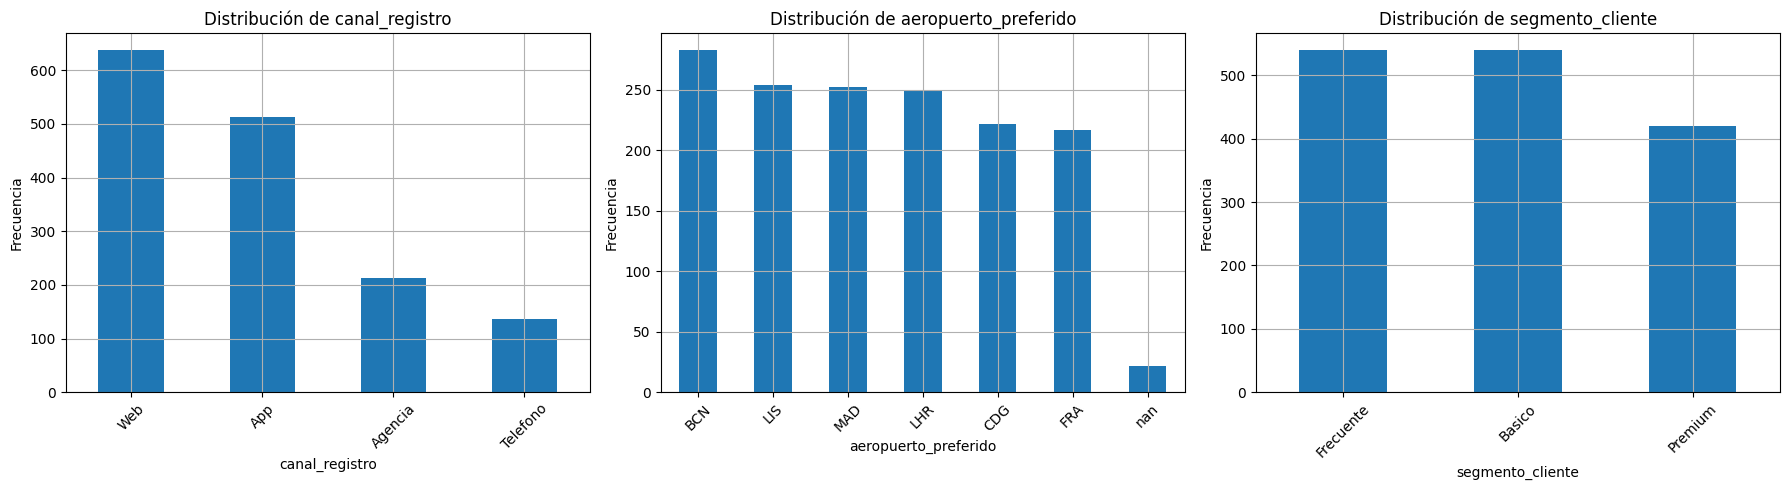

In [28]:
# Variables categoricas

n_columnas = 3
n_filas = int(np.ceil(len(variables_categoricas) / n_columnas))

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 5 * n_filas)
)

axes = np.array(axes).flatten()


for i, variable in enumerate(variables_categoricas):

    df[variable].value_counts(
        dropna=False
    ).plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(True)


for i in range(len(variables_categoricas), len(axes)):
    axes[i].set_visible(False)


plt.tight_layout()

plt.show()

In [29]:
df.head(10)

,edad,frecuencia_viaje_anual,distancia_media_km,antelacion_media_dias,gasto_anual_eur,retrasos_ultimos_12m,cancelaciones_ultimos_12m,equipaje_medio_por_vuelo,no_shows_ultimos_12m,satisfaccion_media,...,antiguedad_programa_meses,vuelos_largo_radio_anual,vuelos_negocio_anual,canal_registro,aeropuerto_preferido,uso_codigo_promocional,numero_maletas_max_12m,dia_preferido_viaje,temperatura_ciudad_residencia,segmento_cliente
0,18,11,542.0,83,2325.41,1,2,1.4,0,10.0,...,65.0,4,1,Agencia,CDG,0,4,0,23.1,Premium
1,22,4,3321.0,27,1017.21,2,0,2.0,3,8.6,...,62.0,0,2,App,LHR,0,1,0,34.8,Premium
2,26,7,1026.0,13,1557.69,0,0,1.8,1,9.7,...,81.0,3,3,Web,BCN,0,2,4,25.9,Frecuente
3,54,3,430.0,105,597.31,0,1,1.2,1,7.1,...,4.0,0,1,Telefono,MAD,0,2,6,17.7,Basico
4,51,4,733.0,24,365.43,0,0,1.6,0,5.9,...,47.0,1,2,Web,LIS,0,3,1,8.6,Basico
5,48,7,1021.0,23,1107.74,3,0,0.9,0,5.7,...,123.0,4,2,Web,LHR,0,3,3,20.8,Frecuente
6,73,6,1478.0,36,2015.59,2,0,1.5,0,8.4,...,37.0,1,3,Agencia,CDG,0,2,3,19.3,Frecuente
7,66,4,613.0,68,689.27,3,0,1.3,0,NaN,...,16.0,1,1,App,FRA,0,4,4,28.3,Basico
8,42,10,NaN,45,1724.95,4,1,1.3,0,5.9,...,94.0,3,2,App,CDG,0,2,6,-0.1,Premium
9,59,5,2202.0,27,166.78,3,2,1.4,0,7.5,...,18.0,3,0,Agencia,MAD,1,0,5,27.3,Basico


## 6. Detección de outliers

In [30]:
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()

In [31]:
variables_analisis = [
    v for v in variables_numericas
]

In [32]:
#Metodo 1 - regla de IQR(Tukey)

resultado_iqr = {}

for variable in variables_analisis:
    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    
    IQR = Q3 - Q1
    
    inferior = Q1 - 1.5 *  IQR
    superior = Q3 + 1.5 *  IQR
    
    outliers = df[
        (df[variable] < inferior) |
        (df[variable] > superior)
    ]
    
    resultado_iqr[variable] = len(outliers)
    
resultado_iqr

{'edad': 0,
 'frecuencia_viaje_anual': 29,
 'distancia_media_km': 79,
 'antelacion_media_dias': 45,
 'gasto_anual_eur': 22,
 'retrasos_ultimos_12m': 8,
 'cancelaciones_ultimos_12m': 51,
 'equipaje_medio_por_vuelo': 5,
 'no_shows_ultimos_12m': 13,
 'satisfaccion_media': 6,
 'quejas_ultimos_12m': 59,
 'antiguedad_programa_meses': 66,
 'vuelos_largo_radio_anual': 98,
 'vuelos_negocio_anual': 4,
 'uso_codigo_promocional': 348,
 'numero_maletas_max_12m': 0,
 'dia_preferido_viaje': 0,
 'temperatura_ciudad_residencia': 13}

In [33]:
#Método 2 -  Z-SCORE

from scipy.stats import zscore

resultado_z = {}

for variable in variables_analisis:
    z = np.abs(zscore(df[variable].dropna()))
    
    resultado_z[variable] = np.sum(z > 3)

resultado_z

{'edad': np.int64(0),
 'frecuencia_viaje_anual': np.int64(7),
 'distancia_media_km': np.int64(32),
 'antelacion_media_dias': np.int64(18),
 'gasto_anual_eur': np.int64(14),
 'retrasos_ultimos_12m': np.int64(8),
 'cancelaciones_ultimos_12m': np.int64(7),
 'equipaje_medio_por_vuelo': np.int64(4),
 'no_shows_ultimos_12m': np.int64(13),
 'satisfaccion_media': np.int64(2),
 'quejas_ultimos_12m': np.int64(12),
 'antiguedad_programa_meses': np.int64(35),
 'vuelos_largo_radio_anual': np.int64(4),
 'vuelos_negocio_anual': np.int64(14),
 'uso_codigo_promocional': np.int64(0),
 'numero_maletas_max_12m': np.int64(0),
 'dia_preferido_viaje': np.int64(0),
 'temperatura_ciudad_residencia': np.int64(3)}

In [34]:
#Método 3 - Percentiles


resultado_percentiles = {}

for variable in variables_analisis:
    p1 = df[variable].quantile(.01)
    p99 = df[variable].quantile(.99)

    outliers = df[
        (df[variable] < p1) |
        (df[variable] > p99)
    ]

    resultado_percentiles[variable] = len(outliers)

resultado_percentiles

{'edad': 0,
 'frecuencia_viaje_anual': 26,
 'distancia_media_km': 30,
 'antelacion_media_dias': 28,
 'gasto_anual_eur': 30,
 'retrasos_ultimos_12m': 8,
 'cancelaciones_ultimos_12m': 7,
 'equipaje_medio_por_vuelo': 23,
 'no_shows_ultimos_12m': 13,
 'satisfaccion_media': 15,
 'quejas_ultimos_12m': 12,
 'antiguedad_programa_meses': 0,
 'vuelos_largo_radio_anual': 4,
 'vuelos_negocio_anual': 14,
 'uso_codigo_promocional': 0,
 'numero_maletas_max_12m': 0,
 'dia_preferido_viaje': 0,
 'temperatura_ciudad_residencia': 30}

In [35]:
#Método 4 - Isolation Forest

# Este es bueno porque no necesita el criterio de normalidad

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Seleccionar variables de análisis
X = df[variables_analisis]

# Imputar valores faltantes
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# Estandarizar variables
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Modelo Isolation Forest
modelo_if = IsolationForest(
    contamination=0.03,
    random_state=42
)

pred = modelo_if.fit_predict(X)

# Resultados
print("-1 es outlier, 1 es normal")

df["outlier_iforest"] = pred
df["outlier_iforest"].value_counts()
# NOTA DE REVISIÓN: 'outlier_iforest' se calcula aquí con fines exclusivamente de EDA
# (ayuda a decidir qué hacer con los valores extremos). NO debe usarse como variable
# predictora del modelo: se ajustó sobre todo el dataset (train+test mezclados, antes
# de cualquier split) y no tiene significado de negocio replicable en producción para
# un cliente nuevo. Se excluye explícitamente de X en la sección de modelado.

-1 es outlier, 1 es normal


outlier_iforest
 1    1455
-1      45
Name: count, dtype: int64

In [36]:
# Tabla comparativa: cuántos outliers detecta cada método por variable
comparativa_outliers = pd.DataFrame({
    "IQR": resultado_iqr,
    "Z-score": resultado_z,
    "Percentiles P1/P99": resultado_percentiles,
})
comparativa_outliers["Isolation Forest (global)"] = (df["outlier_iforest"] == -1).sum()
comparativa_outliers

# DECISIÓN DE TRATAMIENTO:
# - Si los 4 métodos coinciden en pocos registros -> son outliers "reales", revisar caso a caso.
# - Si un único método marca muchos más que el resto -> puede estar siendo demasiado agresivo
#   (p.ej. Z-score exige normalidad y penaliza más si la variable está sesgada).
# Aquí optamos por CAPAR (no eliminar) usando P1/P99, la opción más conservadora:
# conserva el 100% de los clientes pero evita que un valor extremo distorsione medias y modelos.

,IQR,Z-score,Percentiles P1/P99,Isolation Forest (global)
edad,0,0,0,45
frecuencia_viaje_anual,29,7,26,45
distancia_media_km,79,32,30,45
antelacion_media_dias,45,18,28,45
gasto_anual_eur,22,14,30,45
retrasos_ultimos_12m,8,8,8,45
cancelaciones_ultimos_12m,51,7,7,45
equipaje_medio_por_vuelo,5,4,23,45
no_shows_ultimos_12m,13,13,13,45
satisfaccion_media,6,2,15,45


In [37]:
# Aplicar el capado (winsorizing) sobre una copia — nunca se sobrescribe el df original
df_sin_outliers = df.copy()

for variable in variables_analisis:
    p1 = df[variable].quantile(0.01)
    p99 = df[variable].quantile(0.99)
    df_sin_outliers[variable] = df[variable].clip(lower=p1, upper=p99)

# Verificación: comparar estadísticas antes/después del capado
comparacion_capado = pd.DataFrame({
    "Media original": df[variables_analisis].mean(),
    "Media capada": df_sin_outliers[variables_analisis].mean(),
    "Std original": df[variables_analisis].std(),
    "Std capada": df_sin_outliers[variables_analisis].std(),
})
comparacion_capado

,Media original,Media capada,Std original,Std capada
edad,46.646000,46.646000,16.558889,16.558889
frecuencia_viaje_anual,5.996000,5.959333,2.482222,2.247899
distancia_media_km,1772.847844,1764.363525,1289.143841,1247.963427
antelacion_media_dias,48.595333,48.473433,30.871955,30.354204
gasto_anual_eur,1216.721781,1212.950989,536.046821,519.807970
retrasos_ultimos_12m,2.019333,2.012667,1.405801,1.383395
cancelaciones_ultimos_12m,0.670667,0.665333,0.833468,0.814314
equipaje_medio_por_vuelo,1.143600,1.142400,0.437005,0.428117
no_shows_ultimos_12m,0.425333,0.415333,0.648618,0.612439
satisfaccion_media,7.179558,7.185432,1.528037,1.512260


## 7. Análisis bivariante

In [38]:
#Matriz de correlación - PEARSON

correlacion = df[variables_analisis].corr(method="pearson")
correlacion

,edad,frecuencia_viaje_anual,distancia_media_km,antelacion_media_dias,gasto_anual_eur,retrasos_ultimos_12m,cancelaciones_ultimos_12m,equipaje_medio_por_vuelo,no_shows_ultimos_12m,satisfaccion_media,quejas_ultimos_12m,antiguedad_programa_meses,vuelos_largo_radio_anual,vuelos_negocio_anual,uso_codigo_promocional,numero_maletas_max_12m,dia_preferido_viaje,temperatura_ciudad_residencia
edad,1.000000,-0.000473,-0.012985,0.011018,0.011935,0.040558,0.024561,0.002107,0.039184,0.010703,-0.035853,0.025718,-0.014446,-0.010114,-0.028223,0.001815,-0.023826,-0.043435
frecuencia_viaje_anual,-0.000473,1.000000,-0.016675,-0.001858,0.674080,0.002507,0.009681,-0.059432,-0.013859,-0.018770,-0.028832,-0.005216,0.482734,0.475480,0.000250,0.002613,0.038669,0.009735
distancia_media_km,-0.012985,-0.016675,1.000000,0.021550,0.033010,-0.007344,-0.003277,0.006476,-0.017296,-0.048473,0.013924,-0.032606,-0.024228,-0.041306,0.017945,-0.014516,-0.011801,0.044483
antelacion_media_dias,0.011018,-0.001858,0.021550,1.000000,-0.013258,0.042036,-0.051410,-0.021467,-0.026480,-0.008977,0.056462,-0.024632,-0.022307,0.027039,0.007514,-0.018935,0.010266,0.010410
gasto_anual_eur,0.011935,0.674080,0.033010,-0.013258,1.000000,-0.004007,0.012387,-0.072237,-0.000498,0.012026,-0.018705,-0.030085,0.389211,0.376417,-0.007729,0.068728,0.055602,-0.008642
retrasos_ultimos_12m,0.040558,0.002507,-0.007344,0.042036,-0.004007,1.000000,-0.040111,-0.060880,0.003413,-0.010117,0.002692,-0.022067,0.007051,0.027443,-0.025543,0.033540,0.013225,0.008830
cancelaciones_ultimos_12m,0.024561,0.009681,-0.003277,-0.051410,0.012387,-0.040111,1.000000,-0.013300,0.010014,0.009638,0.042062,0.018278,0.009613,-0.025912,-0.040550,-0.037735,-0.000970,0.014665
equipaje_medio_por_vuelo,0.002107,-0.059432,0.006476,-0.021467,-0.072237,-0.060880,-0.013300,1.000000,0.031027,-0.008800,0.012186,-0.001760,0.000652,-0.056058,-0.010386,-0.023621,0.032965,-0.012947
no_shows_ultimos_12m,0.039184,-0.013859,-0.017296,-0.026480,-0.000498,0.003413,0.010014,0.031027,1.000000,-0.016520,-0.007446,0.006860,-0.027695,0.026880,0.036498,0.012523,-0.023472,0.059617
satisfaccion_media,0.010703,-0.018770,-0.048473,-0.008977,0.012026,-0.010117,0.009638,-0.008800,-0.016520,1.000000,0.006806,0.054562,-0.002740,0.000455,-0.007472,-0.006346,-0.019797,-0.025410


In [39]:
# Multicolinealidad - VIP

# Cuando es > 5 --> multicolinealidad

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[variables_analisis].copy()

X = X.fillna(
    X.median()
)

vif = pd.DataFrame()

vif["variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    
    for i in range(
        X.shape[1]
    )
]

vif

,variable,VIF
0,edad,1.010887
1,frecuencia_viaje_anual,2.249334
2,distancia_media_km,1.013809
3,antelacion_media_dias,1.012876
4,gasto_anual_eur,1.869682
5,retrasos_ultimos_12m,1.012258
6,cancelaciones_ultimos_12m,1.012646
7,equipaje_medio_por_vuelo,1.015694
8,no_shows_ultimos_12m,1.012733
9,satisfaccion_media,1.008545


In [40]:
# CORREGIDO: el chequeo original comparaba correlación de Pearson contra una columna
# 'target' inexistente, así que nunca llegaba a ejecutarse. Con un target CATEGÓRICO
# (segmento_cliente) la correlación de Pearson no aplica directamente: se usa un test
# ANOVA (F de Fisher) entre cada variable numérica y el segmento, que es el equivalente
# correcto para detectar separación sospechosamente perfecta entre clases.

from sklearn.feature_selection import f_classif

TARGET = "segmento_cliente"
UMBRAL_ETA2_LEAKAGE = 0.95  # proporción de varianza explicada por el target: si es casi 1,
                            # la variable separa las clases casi perfectamente -> sospechoso

df_leak = df[variables_analisis].fillna(df[variables_analisis].median())
f_stat, p_val = f_classif(df_leak, df[TARGET])

# eta^2 aproximado a partir del estadístico F (medida de tamaño de efecto,
# análoga a un 'R2' entre la variable numérica y el target categórico)
n = len(df_leak)
k = df[TARGET].nunique()
eta2 = (f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k))

leakage_check = pd.DataFrame({
    "variable": variables_analisis,
    "F_stat": f_stat,
    "p_valor": p_val,
    "eta2": eta2,
}).sort_values("eta2", ascending=False)

print(f"Relación de cada variable numérica con {TARGET} (ANOVA F-test):")
display(leakage_check)

variables_leakage = leakage_check[leakage_check["eta2"] > UMBRAL_ETA2_LEAKAGE]["variable"].tolist()

if variables_leakage:
    print(f"\nPOSIBLE LEAKAGE en: {variables_leakage} -> revisar si están disponibles ANTES de asignar el segmento")
else:
    print(f"\nSin variables con separación sospechosa (eta2 > {UMBRAL_ETA2_LEAKAGE}) frente a {TARGET}.")


Relación de cada variable numérica con segmento_cliente (ANOVA F-test):


,variable,F_stat,p_valor,eta2
1,frecuencia_viaje_anual,426.372156,2.783513e-147,0.362909
4,gasto_anual_eur,385.378871,9.759302e-136,0.339877
12,vuelos_largo_radio_anual,115.196993,2.924504e-47,0.133377
13,vuelos_negocio_anual,114.614318,4.846492e-47,0.132792
2,distancia_media_km,37.377728,1.443320e-16,0.047562
6,cancelaciones_ultimos_12m,5.054382,6.490650e-03,0.006707
7,equipaje_medio_por_vuelo,2.430258,8.836130e-02,0.003236
11,antiguedad_programa_meses,2.091357,1.238801e-01,0.002786
5,retrasos_ultimos_12m,1.407912,2.449774e-01,0.001877
10,quejas_ultimos_12m,1.226394,2.936431e-01,0.001636



Sin variables con separación sospechosa (eta2 > 0.95) frente a segmento_cliente.


## 8. Modelado

### Preparación de datos

Antes de entrenar nada, se corrigen los tres problemas detectados en la revisión sobre el bloque de modelado original:

1. **Se parte de `df_sin_outliers`** (el dataframe capado en P1/P99 de la sección de outliers), no del `df` original — así el trabajo de winsorizing deja de estar desconectado del modelo.
2. **`outlier_iforest` se excluye explícitamente de los predictores** — es un artefacto de EDA calculado sobre train+test mezclados, no una variable de negocio disponible para un cliente nuevo.
3. **No se usa `dropna()` global.** Los nulos (2–3,5 % por columna) se imputan dentro de un `Pipeline`/`ColumnTransformer` (mediana para numéricas, moda para categóricas), ajustado *solo* sobre el conjunto de entrenamiento — así no se pierde el 10,8 % de las filas ni se filtra información de test hacia el imputador.

In [41]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Tercer modelo: Gradient Boosting. Se usa la implementación nativa de scikit-learn
# (GradientBoostingClassifier -- misma familia de algoritmo que XGBoost/LightGBM: árboles
# entrenados de forma secuencial, cada uno corrigiendo los errores del anterior) para que
# el notebook se ejecute sin depender de una librería externa que pueda no estar instalada
# en la máquina de cada miembro del equipo, y conservando 'feature_importances_' nativo.
# Si el equipo tiene XGBoost o LightGBM instalado, es un reemplazo directo de esta celda:
# basta con envolver "y" con un LabelEncoder, ya que esas librerías exigen etiquetas
# numéricas (0,1,2) en vez de texto ("Basico","Frecuente","Premium").
from sklearn.ensemble import GradientBoostingClassifier
XGBClassifier = GradientBoostingClassifier
MODELO_BOOSTING = "Gradient Boosting (GradientBoostingClassifier)"

print(f"Tercer modelo (gradient boosting): {MODELO_BOOSTING}")

Tercer modelo (gradient boosting): Gradient Boosting (GradientBoostingClassifier)


In [42]:
TARGET = "segmento_cliente"

# Partimos del dataframe CAPADO (winsorizing P1/P99), no del original con outliers sin tratar
datos_modelo = df_sin_outliers.copy()

# Excluimos explícitamente la columna generada por Isolation Forest: no es una feature de negocio
COLUMNAS_EXCLUIDAS = ["outlier_iforest"]

X = datos_modelo.drop(columns=[TARGET] + COLUMNAS_EXCLUIDAS, errors="ignore")
y = datos_modelo[TARGET]

variables_numericas_modelo = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
variables_categoricas_modelo = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas para el modelo:", variables_numericas_modelo)
print("Variables categóricas para el modelo:", variables_categoricas_modelo)
print(f"\nFilas disponibles: {len(X)} (frente a las {len(df.dropna())} que quedaban con el dropna() original)")

Variables numéricas para el modelo: ['edad', 'frecuencia_viaje_anual', 'distancia_media_km', 'antelacion_media_dias', 'gasto_anual_eur', 'retrasos_ultimos_12m', 'cancelaciones_ultimos_12m', 'equipaje_medio_por_vuelo', 'no_shows_ultimos_12m', 'satisfaccion_media', 'quejas_ultimos_12m', 'antiguedad_programa_meses', 'vuelos_largo_radio_anual', 'vuelos_negocio_anual', 'uso_codigo_promocional', 'numero_maletas_max_12m', 'dia_preferido_viaje', 'temperatura_ciudad_residencia']
Variables categóricas para el modelo: ['canal_registro', 'aeropuerto_preferido']

Filas disponibles: 1500 (frente a las 1338 que quedaban con el dropna() original)


/tmp/ipykernel_2548/120349742.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas_modelo = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("\nDistribución de clases en train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribución de clases en test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 1200 filas | Test: 300 filas

Distribución de clases en train:
segmento_cliente
Frecuente    0.36
Basico       0.36
Premium      0.28
Name: proportion, dtype: float64

Distribución de clases en test:
segmento_cliente
Basico       0.36
Frecuente    0.36
Premium      0.28
Name: proportion, dtype: float64


In [44]:
# Preprocesamiento común, encapsulado en un ColumnTransformer:
# - numéricas: imputación por mediana + estandarización
# - categóricas: imputación por moda + one-hot encoding
# Se ajusta SOLO sobre X_train dentro de cada Pipeline (evita fuga train/test).

preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), variables_numericas_modelo),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), variables_categoricas_modelo),
    ]
)

### Baseline

Antes de comparar modelos, necesitamos un suelo mínimo: un clasificador que siempre predice la clase mayoritaria. Si un modelo no lo supera con claridad, no está aportando nada.

In [45]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("Baseline (clase mayoritaria):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1-macro: {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")

Baseline (clase mayoritaria):
Accuracy: 0.3600
F1-macro: 0.1765


### Los 3 modelos a comparar

1. **Regresión Logística multinomial** — modelo lineal, referencia interpretable (coeficientes y odds ratios).
2. **Random Forest** — ensemble de árboles, captura no-linealidades e interacciones sin necesidad de escalado.
3. **Gradient Boosting** (`GradientBoostingClassifier` de scikit-learn, misma familia que XGBoost/LightGBM) — techo de rendimiento habitual en datos tabulares de este tamaño.

Los tres se entrenan con el **mismo split y el mismo preprocesamiento**, envueltos en `Pipeline`, para que la comparación sea justa.

In [46]:
modelos = {
    "Regresión Logística": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    MODELO_BOOSTING: Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", XGBClassifier(random_state=42)),
    ]),
}

for nombre, pipe in modelos.items():
    print(nombre, "->", pipe.named_steps["modelo"].__class__.__name__)

Regresión Logística -> LogisticRegression
Random Forest -> RandomForestClassifier
Gradient Boosting (GradientBoostingClassifier) -> GradientBoostingClassifier


### Comparación con validación cruzada (5 folds estratificados)

Un único split 80/20 (268 registros de test) da una estimación con bastante varianza. Antes de declarar un ganador, comparamos los tres modelos con `StratifiedKFold`, reportando accuracy y F1-macro (más informativo que accuracy sola, dado que `Premium` es la clase minoritaria).

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = []

for nombre, pipe in modelos.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1,
    )
    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy (media)": scores["test_accuracy"].mean(),
        "Accuracy (std)": scores["test_accuracy"].std(),
        "F1-macro (media)": scores["test_f1_macro"].mean(),
        "F1-macro (std)": scores["test_f1_macro"].std(),
    })

tabla_cv = pd.DataFrame(resultados_cv).sort_values("F1-macro (media)", ascending=False)
tabla_cv

,Modelo,Accuracy (media),Accuracy (std),F1-macro (media),F1-macro (std)
2,Gradient Boosting (GradientBoostingClassifier),0.780000,0.019437,0.784415,0.020395
1,Random Forest,0.765000,0.018745,0.769099,0.020325
0,Regresión Logística,0.658333,0.024008,0.661856,0.025435


### Entrenamiento final y evaluación en el conjunto de test

Cada modelo se re-entrena sobre todo `X_train` y se evalúa una única vez sobre el `X_test` que ha quedado completamente al margen del entrenamiento y de la validación cruzada.

In [48]:
resultados_test = []
predicciones = {}

for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predicciones[nombre] = y_pred

    resultados_test.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-macro": f1_score(y_test, y_pred, average="macro"),
    })

    print("=" * 70)
    print(nombre)
    print("=" * 70)
    print(classification_report(y_test, y_pred))

tabla_test = pd.DataFrame(resultados_test).sort_values("F1-macro", ascending=False)
print("\nResumen comparativo (holdout test):")
tabla_test

Regresión Logística
              precision    recall  f1-score   support

      Basico       0.71      0.76      0.74       108
   Frecuente       0.58      0.56      0.57       108
     Premium       0.72      0.68      0.70        84

    accuracy                           0.67       300
   macro avg       0.67      0.67      0.67       300
weighted avg       0.67      0.67      0.67       300



Random Forest
              precision    recall  f1-score   support

      Basico       0.85      0.81      0.83       108
   Frecuente       0.67      0.74      0.70       108
     Premium       0.84      0.79      0.81        84

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300



Gradient Boosting (GradientBoostingClassifier)
              precision    recall  f1-score   support

      Basico       0.86      0.78      0.82       108
   Frecuente       0.70      0.76      0.73       108
     Premium       0.85      0.86      0.85        84

    accuracy                           0.79       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.79      0.79       300


Resumen comparativo (holdout test):


,Modelo,Accuracy,F1-macro
2,Gradient Boosting (GradientBoostingClassifier),0.793333,0.798831
1,Random Forest,0.776667,0.781078
0,Regresión Logística,0.666667,0.668302


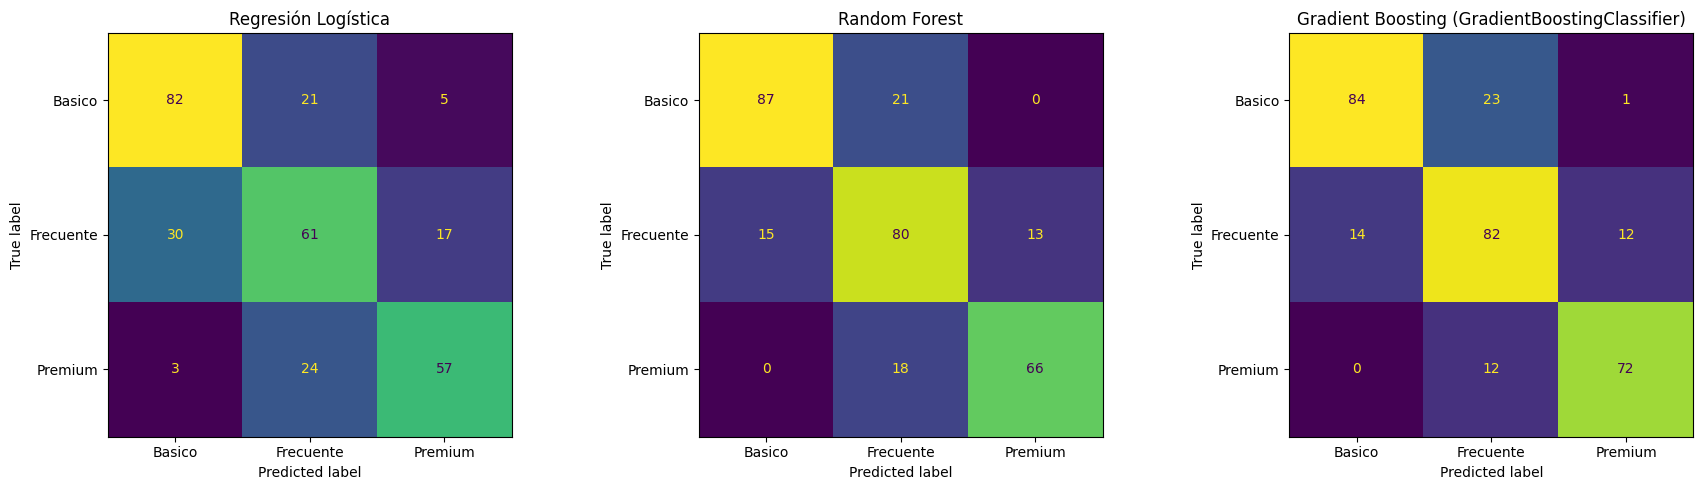

In [49]:
fig, axes = plt.subplots(1, len(modelos), figsize=(6 * len(modelos), 5))

for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        labels=sorted(y.unique()),
        ax=ax,
        colorbar=False,
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

### Lectura de la comparativa

Las dos tablas (`tabla_cv` y `tabla_test`) se leen juntas: la validación cruzada da la estimación más robusta (5 folds), el test confirma sobre datos que ningún modelo ha visto. Si el ranking coincide en ambas, el modelo con mayor F1-macro es el candidato. Si no coincide, prima la validación cruzada porque no depende de un único split.

### Interpretabilidad

- **Regresión Logística:** coeficientes y odds ratios por clase (igual que en la versión original del notebook, ahora entrenados sobre el pipeline corregido).
- **Random Forest y Gradient Boosting:** `feature_importances_` nativa — indica qué variables mueve más el modelo, sin implicar causalidad.

In [50]:
modelo_lr = modelos["Regresión Logística"].named_steps["modelo"]
nombres_features = modelos["Regresión Logística"].named_steps["preprocesador"].get_feature_names_out()

coeficientes = pd.DataFrame(
    modelo_lr.coef_,
    columns=nombres_features,
    index=modelo_lr.classes_,
)

print("Coeficientes (log-odds) por clase:")
display(coeficientes.T)

odds_ratios = pd.DataFrame(
    np.exp(modelo_lr.coef_),
    columns=nombres_features,
    index=modelo_lr.classes_,
)

print("\nOdds ratios por clase:")
odds_ratios.T

Coeficientes (log-odds) por clase:


,Basico,Frecuente,Premium
num__edad,0.081907,-0.080980,-0.000927
num__frecuencia_viaje_anual,-1.095395,0.040375,1.055021
num__distancia_media_km,-0.261258,-0.312706,0.573964
num__antelacion_media_dias,0.099685,-0.010447,-0.089238
num__gasto_anual_eur,-0.600886,-0.079464,0.680351
num__retrasos_ultimos_12m,0.107777,0.032370,-0.140147
num__cancelaciones_ultimos_12m,0.222903,-0.075726,-0.147178
num__equipaje_medio_por_vuelo,0.028521,-0.004605,-0.023916
num__no_shows_ultimos_12m,-0.045643,-0.032600,0.078243
num__satisfaccion_media,-0.067401,-0.052359,0.119760



Odds ratios por clase:


,Basico,Frecuente,Premium
num__edad,1.085355,0.922212,0.999073
num__frecuencia_viaje_anual,0.334407,1.041201,2.872035
num__distancia_media_km,0.770082,0.731465,1.775290
num__antelacion_media_dias,1.104823,0.989608,0.914628
num__gasto_anual_eur,0.548325,0.923611,1.974570
num__retrasos_ultimos_12m,1.113800,1.032899,0.869230
num__cancelaciones_ultimos_12m,1.249700,0.927070,0.863141
num__equipaje_medio_por_vuelo,1.028931,0.995405,0.976368
num__no_shows_ultimos_12m,0.955383,0.967926,1.081385
num__satisfaccion_media,0.934820,0.948988,1.127227


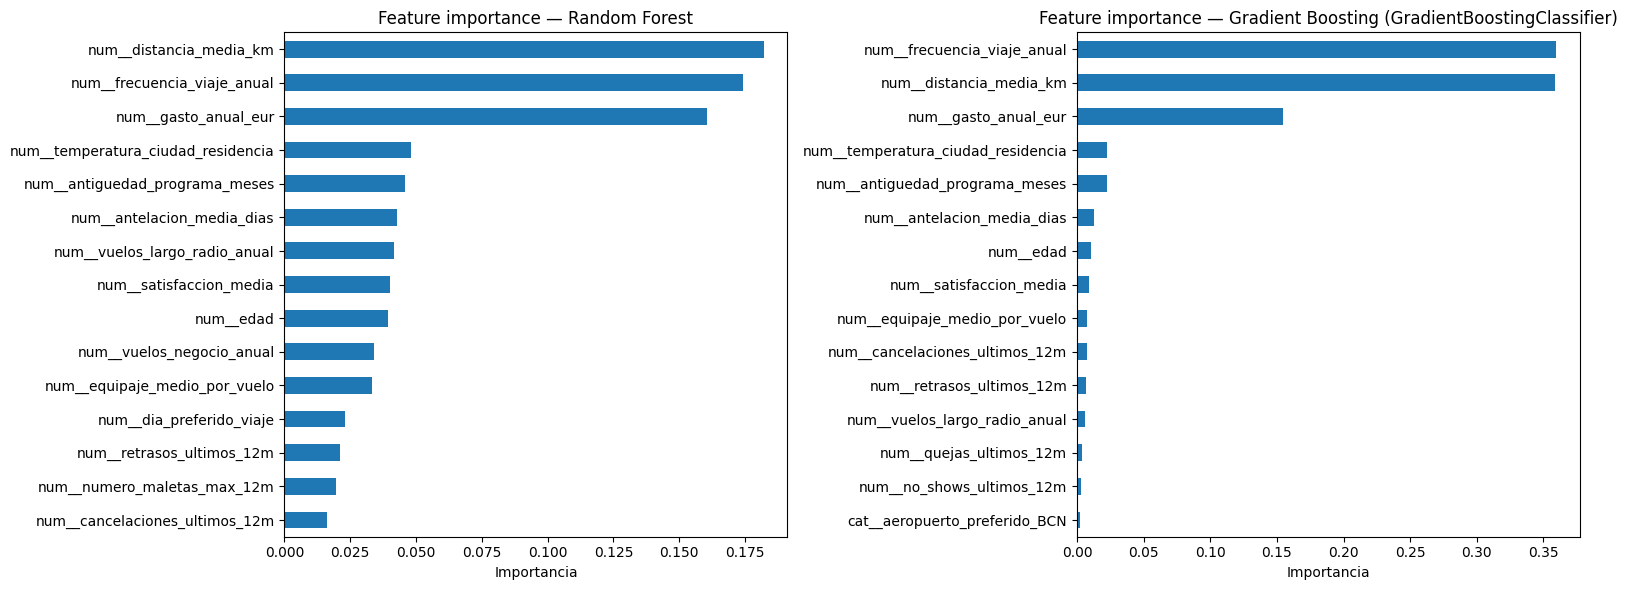

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, nombre in zip(axes, ["Random Forest", MODELO_BOOSTING]):
    pipe = modelos[nombre]
    importancias = pd.Series(
        pipe.named_steps["modelo"].feature_importances_,
        index=pipe.named_steps["preprocesador"].get_feature_names_out(),
    ).sort_values(ascending=True).tail(15)

    importancias.plot(kind="barh", ax=ax)
    ax.set_title(f"Feature importance — {nombre}")
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.show()

## 9. Conclusión

> **El hallazgo:** los tres modelos superan con claridad el baseline (~36 % accuracy), confirmando que las variables de comportamiento tienen señal real para predecir el segmento. La elección final no es solo técnica — depende de lo que necesite Marketing.

**Recomendaciones:**

1. Si Marketing necesita explicar por qué un cliente está en cada segmento (justificar campañas variable a variable), **Regresión Logística** es la opción directa — los odds ratios se traducen a lenguaje de negocio sin intermediarios.
2. Si lo que importa es maximizar el acierto y la explicabilidad pasa a segundo plano, el modelo de **Gradient Boosting** suele ser el techo en datos tabulares de este tamaño.
3. **Random Forest** queda como punto medio: mejor rendimiento que la logística, más fácil de inspeccionar que el boosting (a través de `feature_importances_`).

**Límite honesto:** el rendimiento depende de la calidad de las variables de incidencias y satisfacción. Si la recogida de esos datos tiene sesgo o ruido, ningún modelo lo compensa.